# PySpark Notebook

A structured walkthrough of PySpark covering RDDs, DataFrames, data cleaning, feature engineering, visualisation, and ML.

## 1. Setup

In [1]:
from pyspark import SparkContext
from pyspark.sql import SparkSession

sc    = SparkContext("local", "PySparkIntro")
spark = SparkSession.builder.appName("PySparkIntro").getOrCreate()

## 2. RDD Basics

Create an RDD from a list, then apply `map` and `filter` transformations.

In [2]:
data = [1, 2, 3, 4, 5, 7, 8, 9, 10]
rdd = sc.parallelize(data)

square_rdd = rdd.map(lambda x: x * x)
even_rdd   = rdd.filter(lambda x: x % 2 == 0)

print("Squares:     ", square_rdd.collect())
print("Evens:       ", even_rdd.collect())
print("Square count:", square_rdd.count())

Squares:      [1, 4, 9, 16, 25, 49, 64, 81, 100]
Evens:        [2, 4, 8, 10]
Square count: 9


## 3. DataFrames — Schema & Creation

In [3]:
from pyspark.sql.types import StructType, StructField, IntegerType, StringType

employee_schema = StructType([
    StructField("id",     IntegerType(), True),
    StructField("name",   StringType(),  True),
    StructField("Salary", IntegerType(), True),
    StructField("age",    IntegerType(), True),
    StructField("city",   StringType(),  True),
])

employee_data = [
    (1, "shaik",  50000, 25, "Hyderabad"),
    (2, "sai",    60000, 30, "Bangalore"),
    (3, "kumar",  55000, 28, "Chennai"),
    (4, "raju",   70000, 35, "Mumbai"),
]

df = spark.createDataFrame(employee_data, employee_schema)
df.show()

+---+-----+------+---+---------+
| id| name|Salary|age|     city|
+---+-----+------+---+---------+
|  1|shaik| 50000| 25|Hyderabad|
|  2|  sai| 60000| 30|Bangalore|
|  3|kumar| 55000| 28|  Chennai|
|  4| raju| 70000| 35|   Mumbai|
+---+-----+------+---+---------+



## 4. Reading a CSV File

Load `enjoysport.csv` — a small weather/sport dataset.

In [4]:
df_sport = spark.read.csv("enjoysport.csv", header=True, inferSchema=True)
df_sport.printSchema()
df_sport.show()

root
 |-- sunny: string (nullable = true)
 |-- warm1: string (nullable = true)
 |-- normal: string (nullable = true)
 |-- strong: string (nullable = true)
 |-- warm4: string (nullable = true)
 |-- same: string (nullable = true)
 |-- yes: string (nullable = true)

+-----+-----+------+------+-----+------+---+
|sunny|warm1|normal|strong|warm4|  same|yes|
+-----+-----+------+------+-----+------+---+
|sunny| warm|  high|strong| warm|  same|yes|
|rainy| cold|  high|strong| warm|change| no|
|sunny| warm|  high|strong| cool|change|yes|
+-----+-----+------+------+-----+------+---+



## 5. Handling Missing Values

Fill `None` entries using computed mean age.

In [5]:
data_with_nulls = [
    (1, "shaik", 50000, 25, "Hyderabad"),
    (2, "sai",   60000, 30, "Bangalore"),
    (3, "kumar", 55000, 28, None),
    (4, "raju",  70000, None, "Mumbai"),
]

df_nulls = spark.createDataFrame(data_with_nulls, employee_schema)
df_nulls.show()

mean_age = df_nulls.agg({"age": "avg"}).collect()[0][0]
print(f"Mean age: {mean_age:.1f}")

df_filled = df_nulls.na.fill({"age": int(mean_age), "city": "Unknown"})
df_filled.show()

+---+-----+------+----+---------+
| id| name|Salary| age|     city|
+---+-----+------+----+---------+
|  1|shaik| 50000|  25|Hyderabad|
|  2|  sai| 60000|  30|Bangalore|
|  3|kumar| 55000|  28|     NULL|
|  4| raju| 70000|NULL|   Mumbai|
+---+-----+------+----+---------+

Mean age: 27.7
+---+-----+------+---+---------+
| id| name|Salary|age|     city|
+---+-----+------+---+---------+
|  1|shaik| 50000| 25|Hyderabad|
|  2|  sai| 60000| 30|Bangalore|
|  3|kumar| 55000| 28|  Unknown|
|  4| raju| 70000| 27|   Mumbai|
+---+-----+------+---+---------+



## 6. Feature Scaling — MinMax & Standard Scaler

In [6]:
from pyspark.ml.feature import VectorAssembler, MinMaxScaler, StandardScaler

assembler = VectorAssembler(inputCols=["age", "Salary"], outputCol="features")
df_vec = assembler.transform(df)

# MinMax scaling
minmax_model = MinMaxScaler(inputCol="features", outputCol="minmax_features").fit(df_vec)
df_minmax    = minmax_model.transform(df_vec)
df_minmax.select("name", "features", "minmax_features").show(truncate=False)

# Standard scaling
std_model = StandardScaler(inputCol="features", outputCol="std_features",
                            withStd=True, withMean=True).fit(df_vec)
df_std    = std_model.transform(df_vec)
df_std.select("name", "features", "std_features").show(truncate=False)

+-----+--------------+--------------------------+
|name |features      |minmax_features           |
+-----+--------------+--------------------------+
|shaik|[25.0,50000.0]|[0.0,0.0]                 |
|sai  |[30.0,60000.0]|[0.5,0.5]                 |
|kumar|[28.0,55000.0]|[0.30000000000000004,0.25]|
|raju |[35.0,70000.0]|[1.0,1.0]                 |
+-----+--------------+--------------------------+

+-----+--------------+------------------------------------------+
|name |features      |std_features                              |
+-----+--------------+------------------------------------------+
|shaik|[25.0,50000.0]|[-1.0706196407194948,-1.0246950765959597] |
|sai  |[30.0,60000.0]|[0.11895773785772164,0.14638501094227996] |
|kumar|[28.0,55000.0]|[-0.3568732135731649,-0.43915503282683993]|
|raju |[35.0,70000.0]|[1.308535116434938,1.3174650984805198]    |
+-----+--------------+------------------------------------------+



## 7. Descriptive Statistics & Correlation

In [7]:
df.describe(["age", "Salary"]).show()

correlation = df.stat.corr("age", "Salary")
print(f"Pearson correlation (age vs Salary): {correlation:.4f}")

+-------+-----------------+-----------------+
|summary|              age|           Salary|
+-------+-----------------+-----------------+
|  count|                4|                4|
|   mean|             29.5|          58750.0|
| stddev|4.203173404306163|8539.125638299665|
|    min|               25|            50000|
|    max|               35|            70000|
+-------+-----------------+-----------------+

Pearson correlation (age vs Salary): 0.9984


## 8. Visualisation

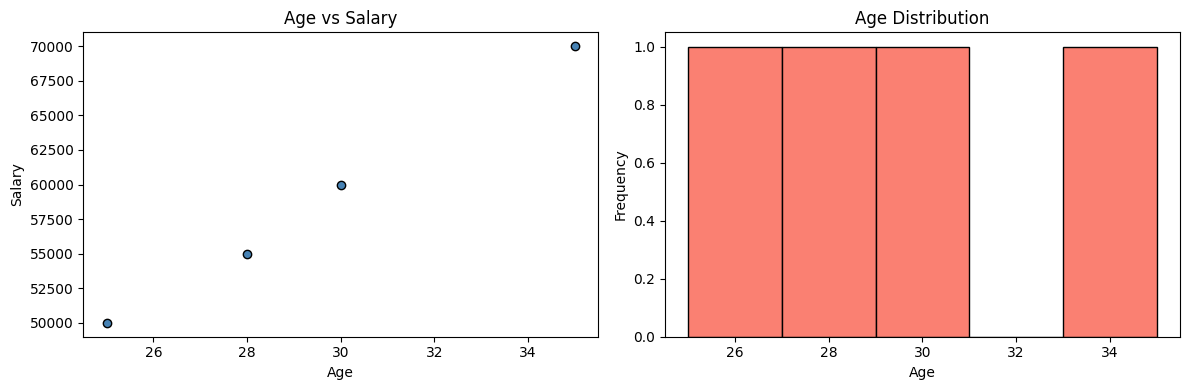

In [8]:
import matplotlib.pyplot as plt

pd_df = df.toPandas()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(pd_df["age"], pd_df["Salary"], color="steelblue", edgecolors="black")
axes[0].set_xlabel("Age"); axes[0].set_ylabel("Salary"); axes[0].set_title("Age vs Salary")

axes[1].hist(pd_df["age"], bins=5, color="salmon", edgecolor="black")
axes[1].set_xlabel("Age"); axes[1].set_ylabel("Frequency"); axes[1].set_title("Age Distribution")

plt.tight_layout()
plt.show()

## 9. Column Transformations

In [9]:
from pyspark.sql.functions import col, concat, lit, avg, min, max, sum
from pyspark.sql.window import Window

# 50% salary raise
df.withColumn("Salary_x1_5", col("Salary") * 1.5).show()

# String concatenation
df.withColumn("Name_and_Role", concat(col("name"), lit(" - Employee"))).show()

# Filter: age >= 30
df.filter(col("age") >= 30).show()

# Average salary
avg_salary = df.agg(avg("Salary")).collect()[0][0]
print(f"Average salary: {avg_salary:,.0f}")

# Grouped stats
df.groupBy("age").agg(
    avg("Salary").alias("avg_salary"),
    max("Salary").alias("max_salary"),
    min("Salary").alias("min_salary"),
).show()

# Cumulative salary
window_spec = Window.orderBy("age")
df.withColumn("Cumulative_Salary", sum("Salary").over(window_spec)).show()

+---+-----+------+---+---------+-----------+
| id| name|Salary|age|     city|Salary_x1_5|
+---+-----+------+---+---------+-----------+
|  1|shaik| 50000| 25|Hyderabad|    75000.0|
|  2|  sai| 60000| 30|Bangalore|    90000.0|
|  3|kumar| 55000| 28|  Chennai|    82500.0|
|  4| raju| 70000| 35|   Mumbai|   105000.0|
+---+-----+------+---+---------+-----------+

+---+-----+------+---+---------+----------------+
| id| name|Salary|age|     city|   Name_and_Role|
+---+-----+------+---+---------+----------------+
|  1|shaik| 50000| 25|Hyderabad|shaik - Employee|
|  2|  sai| 60000| 30|Bangalore|  sai - Employee|
|  3|kumar| 55000| 28|  Chennai|kumar - Employee|
|  4| raju| 70000| 35|   Mumbai| raju - Employee|
+---+-----+------+---+---------+----------------+

+---+----+------+---+---------+
| id|name|Salary|age|     city|
+---+----+------+---+---------+
|  2| sai| 60000| 30|Bangalore|
|  4|raju| 70000| 35|   Mumbai|
+---+----+------+---+---------+

Average salary: 58,750
+---+----------+------

## 10. User-Defined Functions (UDFs)

In [11]:
from pyspark.sql.functions import udf

@udf(StringType())
def add_prefix(name):
    return f"Employee: Mr. {name}"

df.withColumn("Prefixed_Name", add_prefix(col("name"))).show()

@udf(IntegerType())
def lifetime_earnings(salary, age):
    """Salary * years of work (age - 22)."""
    return salary * max(age - 22, 1)

df.withColumn("Lifetime_Earnings", lifetime_earnings(col("Salary"), col("age")))
df.show()

+---+-----+------+---+---------+-------------------+
| id| name|Salary|age|     city|      Prefixed_Name|
+---+-----+------+---+---------+-------------------+
|  1|shaik| 50000| 25|Hyderabad|Employee: Mr. shaik|
|  2|  sai| 60000| 30|Bangalore|  Employee: Mr. sai|
|  3|kumar| 55000| 28|  Chennai|Employee: Mr. kumar|
|  4| raju| 70000| 35|   Mumbai| Employee: Mr. raju|
+---+-----+------+---+---------+-------------------+

+---+-----+------+---+---------+
| id| name|Salary|age|     city|
+---+-----+------+---+---------+
|  1|shaik| 50000| 25|Hyderabad|
|  2|  sai| 60000| 30|Bangalore|
|  3|kumar| 55000| 28|  Chennai|
|  4| raju| 70000| 35|   Mumbai|
+---+-----+------+---+---------+



## 11. Supervised ML — Linear Regression (House Prices)

In [12]:
from pyspark.ml.regression import LinearRegression

house_schema = StructType([
    StructField("SqFt",      IntegerType(), True),
    StructField("Bedrooms",  IntegerType(), True),
    StructField("Bathrooms", IntegerType(), True),
    StructField("Price",     IntegerType(), True),
])

house_data = [
    (1200, 2, 1, 15000), (1500, 3, 0, 20000), (1800, 4, 1, 25000),
    (2000, 5, 0, 30000), (2200, 6, 1, 35000), (2500, 7, 0, 40000),
    (2800, 8, 1, 45000), (3000, 9, 0, 50000),
]

df_house     = spark.createDataFrame(house_data, house_schema)
house_asm    = VectorAssembler(inputCols=["SqFt", "Bedrooms", "Bathrooms"], outputCol="features")
df_house_vec = house_asm.transform(df_house)
train, test  = df_house_vec.randomSplit([0.8, 0.2], seed=42)

lr_model = LinearRegression(featuresCol="features", labelCol="Price").fit(train)
preds    = lr_model.transform(test)
preds.select("features", "Price", "prediction").show()
print(f"R2: {lr_model.summary.r2:.4f}  |  RMSE: {lr_model.summary.rootMeanSquaredError:,.0f}")

+----------------+-----+-----------------+
|        features|Price|       prediction|
+----------------+-----+-----------------+
|[1800.0,4.0,1.0]|25000|26344.85472236789|
|[2800.0,8.0,1.0]|45000|46344.85472236789|
+----------------+-----+-----------------+

R2: 1.0000  |  RMSE: 0


## 12. Unsupervised ML — K-Means Clustering (Customer Spending)

In [13]:
from pyspark.ml.clustering import KMeans

customer_schema = StructType([
    StructField("Customer",                StringType(),  True),
    StructField("Spending_on_electronics", IntegerType(), True),
    StructField("Spending_on_clothing",    IntegerType(), True),
    StructField("Spending_on_grocery",     IntegerType(), True),
])

customer_data = [
    ("Customer1", 10000,  5000,  2000), ("Customer2", 15000,  7000,  3000),
    ("Customer3", 20000, 10000,  5000), ("Customer4", 25000, 12000,  6000),
    ("Customer5", 30000, 15000,  8000), ("Customer6", 35000, 20000, 10000),
    ("Customer7", 40000, 25000, 12000),
]

df_cust     = spark.createDataFrame(customer_data, customer_schema)
cust_asm    = VectorAssembler(
    inputCols=["Spending_on_electronics", "Spending_on_clothing", "Spending_on_grocery"],
    outputCol="features")
df_cust_vec = cust_asm.transform(df_cust)

km_model     = KMeans(featuresCol="features", k=3, seed=42).fit(df_cust_vec)
df_clustered = km_model.transform(df_cust_vec)
df_clustered.select("Customer", "features", "prediction").show()

+---------+--------------------+----------+
| Customer|            features|prediction|
+---------+--------------------+----------+
|Customer1|[10000.0,5000.0,2...|         0|
|Customer2|[15000.0,7000.0,3...|         0|
|Customer3|[20000.0,10000.0,...|         0|
|Customer4|[25000.0,12000.0,...|         0|
|Customer5|[30000.0,15000.0,...|         1|
|Customer6|[35000.0,20000.0,...|         1|
|Customer7|[40000.0,25000.0,...|         2|
+---------+--------------------+----------+



## 13. Dimensionality Reduction — PCA

Reduce the three spending dimensions to two principal components.

+---------+----------+----------------------------------------+
|Customer |prediction|pca_features                            |
+---------+----------+----------------------------------------+
|Customer1|0         |[-11229.141711739972,1429.232559441872] |
|Customer2|0         |[-16579.516158631,2550.210700822566]    |
|Customer3|0         |[-22729.78723747192,2746.2172320019263] |
|Customer4|0         |[-28080.16168436294,3867.195373382621]  |
|Customer5|1         |[-34230.43276320386,4063.2019045619804] |
|Customer6|1         |[-41437.48947796065,2633.7609891023076] |
|Customer7|2         |[-48644.546192717426,1204.3200736426322]|
+---------+----------+----------------------------------------+

Explained variance ratio: [0.9933307543326584, 0.006520927828662932]


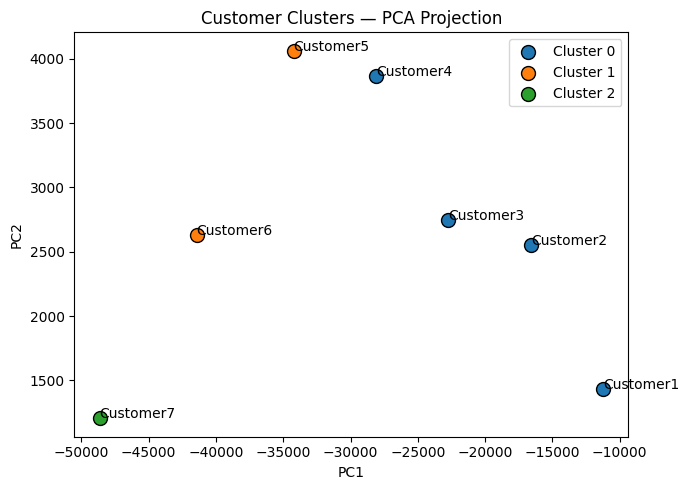

In [15]:
from pyspark.ml.feature import PCA

pca_model = PCA(k=2, inputCol="features", outputCol="pca_features").fit(df_clustered)
df_pca    = pca_model.transform(df_clustered)
df_pca.select("Customer", "prediction", "pca_features").show(truncate=False)
print("Explained variance ratio:", pca_model.explainedVariance.toArray().tolist())

# Convert to pandas and extract PC1/PC2 from the vector
pca_pd = df_pca.select("Customer", "prediction", "pca_features").toPandas()
pca_pd["PC1"] = pca_pd["pca_features"].apply(lambda v: float(v[0]))
pca_pd["PC2"] = pca_pd["pca_features"].apply(lambda v: float(v[1]))

plt.figure(figsize=(7, 5))
for cluster, grp in pca_pd.groupby("prediction"):
    plt.scatter(grp["PC1"], grp["PC2"], label=f"Cluster {cluster}", s=100, edgecolors="black")
    for _, row in grp.iterrows():
        plt.annotate(row["Customer"], (row["PC1"] + 0.02, row["PC2"]))
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("Customer Clusters — PCA Projection")
plt.legend(); plt.tight_layout(); plt.show()